# Week-3: Hands-on DSP using GNU Radio and Sound Card
#### by Murat Sever

## Learning Objectives
In this module you'll: 
* getting familiar with GNU Radio Companion (GRC), 
* signal types, variables, 
* time and frequency domain representations, 
* filter characteristics, 
* basics of DSP (aliasing, filtering, multi-rate signal processing), 
* use sound card within GRC
* apply DSP on sound card

## Prerequisites
General Python knowledge

## GNU Radio
GNU Radio is software radio toolkit that is free and open-source (**FOSS**). It has many DSP blocks which are mostly written in **C++**. You can also write blocks in **Python** though their execution will be slower. GNU Radio also has a built-in **scheduler** to provide blocks with data thay need. Data flow is handled by scheduler. Each block has a specific function.

GNU Radio has no GUI but it comes with an application called **GNURadio Companion (GRC)** so you can add and connect blocks together to build what is called a **flowgraph**. You can find a block by searching from available blocks. After you find your block you can add blocks either by double clicking on it or dragging and dropping it onto the surface of GRC. You can also connect blocks in a Python scrit if you wish. Actually this is what GRC does! It generates a script file to do all connections and start the flowgraph. Every flowgraph starts with a **source** block and terminates with a **sink** block. 

## Task1: Characterizing a real bandpass filter
Below is the first flowgraph we will create. In this example we will examine filter characteristics of a bandpass filter. Filters are fundamental building blocks of DSP. Our flowgraph has one source and two sink blocks. We feed the flowgraph with a **noise source** in order to see filter's spectral characteristics and we use sink blocks to display the resulting spectrum and to hear the sound. Try to change the filter properties and see the effects of change of the filter. 

<center><img src="./lab_dsp_noise_bandpass_filter.png" alt="gsm" style="width: 800px;"/></center>
<center>Figure 1: Characterizing a real bandpass filter and playing its output on the sound card </center>



## Q1. Upload a screenshot below this line showing your sound card's supported sampling rates. (5pts)

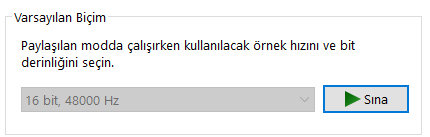

## Q2. Why do we use noise source to obtain filter characteristics? (5pts)

A noise source is useful in filter characterization because it provides a broad spectrum of frequencies especialy gaussian noise, contains all frequencies with equal power within a specified bandwidth.

## Q3. What is the default passband length of this filter? (5pts)

6kHz-4kKz = 2kHz

## Q4. What happens when you play with low frequency & high frequency widgets in the GUI? (5pts)

It wiil straightly affect the passband length and center frequency of our filter. 

## Q5. Locate the python script that GRC generated. Modify it so that it prints the length of the filter. By default how many taps does this filter have? (5pts)

In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

#
# SPDX-License-Identifier: GPL-3.0
#
# GNU Radio Python Flow Graph
# Title: Q1
# GNU Radio version: 3.10.8.0

from PyQt5 import Qt
from gnuradio import qtgui
from gnuradio import analog
from gnuradio import audio
from gnuradio import filter
from gnuradio.filter import firdes
from gnuradio import gr
from gnuradio.fft import window
import sys
import signal
from PyQt5 import Qt
from argparse import ArgumentParser
from gnuradio.eng_arg import eng_float, intx
from gnuradio import eng_notation
from gnuradio.qtgui import Range, RangeWidget
from PyQt5 import QtCore
import sip



class untitled(gr.top_block, Qt.QWidget):

    def __init__(self):
        gr.top_block.__init__(self, "Q1", catch_exceptions=True)
        Qt.QWidget.__init__(self)
        self.setWindowTitle("Q1")
        qtgui.util.check_set_qss()
        try:
            self.setWindowIcon(Qt.QIcon.fromTheme('gnuradio-grc'))
        except BaseException as exc:
            print(f"Qt GUI: Could not set Icon: {str(exc)}", file=sys.stderr)
        self.top_scroll_layout = Qt.QVBoxLayout()
        self.setLayout(self.top_scroll_layout)
        self.top_scroll = Qt.QScrollArea()
        self.top_scroll.setFrameStyle(Qt.QFrame.NoFrame)
        self.top_scroll_layout.addWidget(self.top_scroll)
        self.top_scroll.setWidgetResizable(True)
        self.top_widget = Qt.QWidget()
        self.top_scroll.setWidget(self.top_widget)
        self.top_layout = Qt.QVBoxLayout(self.top_widget)
        self.top_grid_layout = Qt.QGridLayout()
        self.top_layout.addLayout(self.top_grid_layout)

        self.settings = Qt.QSettings("GNU Radio", "untitled")

        try:
            geometry = self.settings.value("geometry")
            if geometry:
                self.restoreGeometry(geometry)
        except BaseException as exc:
            print(f"Qt GUI: Could not restore geometry: {str(exc)}", file=sys.stderr)

        ##################################################
        # Variables
        ##################################################
        self.samp_rate = samp_rate = 48000
        self.low_freq = low_freq = 4000
        self.high_freq = high_freq = 6000

        ##################################################
        # Blocks
        ##################################################

        self.qtgui_sink_x_0 = qtgui.sink_f(
            1024, #fftsize
            window.WIN_BLACKMAN_hARRIS, #wintype
            0, #fc
            samp_rate, #bw
            "", #name
            True, #plotfreq
            True, #plotwaterfall
            True, #plottime
            True, #plotconst
            None # parent
        )
        self.qtgui_sink_x_0.set_update_time(1.0/10)
        self._qtgui_sink_x_0_win = sip.wrapinstance(self.qtgui_sink_x_0.qwidget(), Qt.QWidget)

        self.qtgui_sink_x_0.enable_rf_freq(False)

        self.top_layout.addWidget(self._qtgui_sink_x_0_win)
        self._low_freq_range = Range(4000, 6000, 1, 4000, 200)
        self._low_freq_win = RangeWidget(self._low_freq_range, self.set_low_freq, "'low_freq'", "eng", float, QtCore.Qt.Horizontal)
        self.top_layout.addWidget(self._low_freq_win)
        self._high_freq_range = Range(4000, 6000, 1, 6000, 200)
        self._high_freq_win = RangeWidget(self._high_freq_range, self.set_high_freq, "'high_freq'", "eng", float, QtCore.Qt.Horizontal)
        self.top_layout.addWidget(self._high_freq_win)
        # Define filter taps separately
        filter_taps = firdes.band_pass(
            1,               # Gain
            samp_rate,       # Sampling rate
            low_freq,        # Low cutoff frequency
            high_freq,       # High cutoff frequency
            200,             # Transition width
            window.WIN_HAMMING,  # Window function
            6.76)            # Beta parameter for the window

        # Print the number of filter taps
        print("Number of taps in the filter:", len(filter_taps))

        # Now, use the filter_taps in the band pass filter
        self.band_pass_filter_0 = filter.interp_fir_filter_fff(
            1,
            filter_taps
        )
                                                                                                            
        self.audio_sink_0 = audio.sink(samp_rate, '', True)
        self.analog_noise_source_x_0 = analog.noise_source_f(analog.GR_GAUSSIAN, 1, 0)


        ##################################################
        # Connections
        ##################################################
        self.connect((self.analog_noise_source_x_0, 0), (self.band_pass_filter_0, 0))
        self.connect((self.band_pass_filter_0, 0), (self.audio_sink_0, 0))
        self.connect((self.band_pass_filter_0, 0), (self.qtgui_sink_x_0, 0))


    def closeEvent(self, event):
        self.settings = Qt.QSettings("GNU Radio", "untitled")
        self.settings.setValue("geometry", self.saveGeometry())
        self.stop()
        self.wait()

        event.accept()

    def get_samp_rate(self):
        return self.samp_rate

    def set_samp_rate(self, samp_rate):
        self.samp_rate = samp_rate
        self.band_pass_filter_0.set_taps(firdes.band_pass(1, self.samp_rate, 4000, 6000, 200, window.WIN_HAMMING, 6.76))
        self.qtgui_sink_x_0.set_frequency_range(0, self.samp_rate)

    def get_low_freq(self):
        return self.low_freq

    def set_low_freq(self, low_freq):
        self.low_freq = low_freq

    def get_high_freq(self):
        return self.high_freq

    def set_high_freq(self, high_freq):
        self.high_freq = high_freq




def main(top_block_cls=untitled, options=None):

    qapp = Qt.QApplication(sys.argv)

    tb = top_block_cls()

    tb.start()

    tb.show()

    def sig_handler(sig=None, frame=None):
        tb.stop()
        tb.wait()

        Qt.QApplication.quit()

    signal.signal(signal.SIGINT, sig_handler)
    signal.signal(signal.SIGTERM, sig_handler)

    timer = Qt.QTimer()
    timer.start(500)
    timer.timeout.connect(lambda: None)

    qapp.exec_()

if __name__ == '__main__':
    main()


Number of taps in the filter: 579


## Q6. Modify the python file to generate a table like below to calculate filter tap sizes for transition bandwidths of 100, 200, and 300 for sample rates (SR) of 16000, 32000, and 48000. (15pts)

| Table             | SR=16000      | SR=32000       | SR=48000      |
| -------------     |:-------------:| :-------------:|:-------------:|
| tran. width = 100 |    385        |      771       |      1157     |
| tran. width = 200 |    193        |      385       |      579      |
| tran. width = 300 |     129       |      257       |      385      |

In [3]:
from gnuradio.filter import firdes
from gnuradio.fft import window

sample_rates = [16000, 32000, 48000]
transition_bandwidths = [100, 200, 300]

print("Transition Bandwidths | SR=16000 | SR=32000 | SR=48000")

for trans_bw in transition_bandwidths:
    taps = [len(firdes.band_pass(1, sr, 4000, 6000, trans_bw, window.WIN_HAMMING)) for sr in sample_rates]
    print(f"{trans_bw:21} | {taps[0]:8} | {taps[1]:8} | {taps[2]:7}")


Transition Bandwidths | SR=16000 | SR=32000 | SR=48000
                  100 |      385 |      771 |    1157
                  200 |      193 |      385 |     579
                  300 |      129 |      257 |     385


## Q7. Plot it in a graph below this line. (tap size vs. transition width) (15pts)


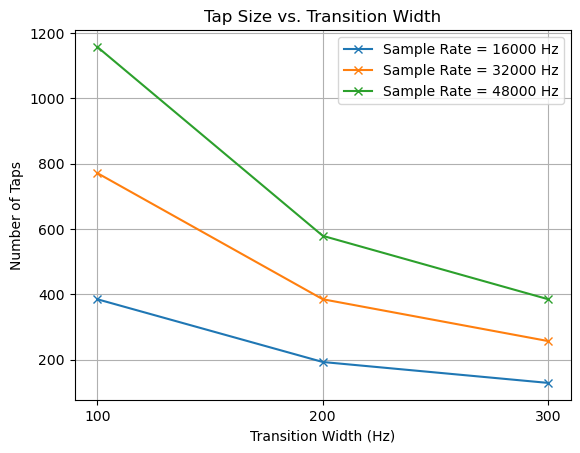

In [4]:
import matplotlib.pyplot as plt
from gnuradio.filter import firdes
from gnuradio.fft import window

sample_rates = [16000, 32000, 48000]
transition_widths = [100, 200, 300]

# Dictionary to store the tap sizes for plotting
tap_sizes = {sr: [] for sr in sample_rates}

# Calculate the number of taps for each sample rate and transition width
for sr in sample_rates:
    for tw in transition_widths:
        filter_taps = firdes.band_pass(1, sr, 4000, 6000, tw, window.WIN_HAMMING, 6.76)
        tap_sizes[sr].append(len(filter_taps))

for sr in sample_rates:
    plt.plot(transition_widths, tap_sizes[sr], marker='x', label=f'Sample Rate = {sr} Hz')

plt.title('Tap Size vs. Transition Width')
plt.xlabel('Transition Width (Hz)')
plt.ylabel('Number of Taps')
plt.xticks(transition_widths)
plt.legend()
plt.grid(True)

## Q8. Comment on your findings on the table and the graph. (10pts)

Looking at the graph, it seems that the transition bandwidth is inversely proportional to the number of taps, because a transition bandwidth of 100 Hz requires more taps than a transition bandwidth of 300 Hz.
When we look at the sample rate, as the number of samples increases, the number of taps required increases. Higher tap counts leads to the frequency selectivity of the filter and makes the transition region sharper.

## Task2: Producing Sound
Sound card is perfect for getting familiar to core DSP concepts. It is easily available and accessible. GNU Radio provides access to sound card via **audio source** and **audio sink** blocks. In this task, we will use a low pass filter. 

Create the flowgraph to generate a sine wave so that you can hear it. We will display the spectrum, too. 
<center><img src="./lab_dsp_tone_decimating_filter.png" alt="gsm" style="width: 1200px;"/></center>
<center>Figure 2: Produce a tone at the sound card </center>

## Q1. What is the default tone's frequency? What musical note does it correspond to? (10pts)

440Hz. The corresponding musical note is A4, which is commonly used as a standard tuning pitch in Western music and known as concert pitch.

## Q2. Look at the documentation of the low pass filter we used from GNU Radio's website to see what parameters it takes. Write its parameters below. (10pts)

## FIR Type (R)
Specify whether input/output is real or complex
Decimation
Decimation rate of filter, must be an integer, and cannot change in realtime.
## Gain (R)
Scaling factor applied to output.
## Sample Rate (R)
Input sample rate.
## Cutoff Freq (R)
Cutoff frequency in Hz
## Transition Width (R)
Transition width between stop-band and pass-band in Hz
## Window (R)
Type of window to use
## Beta (R)
The beta paramater only applies to the Kaiser window.

## Q3. What is the filter's cut-off frequency? (5pts)

Cutoff Freq, 2000Hz

## Q4. Sweep the frequency to see the impact of low pass filter. Write down what you observed below. (10pts)

Increasing the frequency of a cosine signal from 440 Hz to 2 kHz allows the sound to be heard. However, once the frequency exceeds the cutoff frequency of 2 kHz, the sound level significantly decreases. For example, when the frequency increases from 2 kHz to 2.1 kHz, the amplitude of the signal level drops from approximately -21.5 dB to -77.5 dB, indicating a decrease to about 1/630 of the original level.

## Q5. Change the frequency to 48440, 48880, 47560, 51000, 52000, 96440 in order and write down what you hear. (12pts)

48440Hz: Same voice of 440Hz filtered signal

48880Hz: Same voice of 880Hz filtered signal

47560Hz: Same voice of 440Hz filtered signal

51000Hz: Same voice of 3kHz filtered signal (nothing, because of LPF)  

52000Hz: Same voice of 4kHz  filtered signal (nothing, because of LPF)  

96440Hz: Same voice of 440Hz filtered signal

## Q6. Explain your understanding (What happens and why?) (12pts)

Since the sampling frequency is 48 kHz, the Nyquist frequency is 24 kHz.  
Signals above the Nyquist frequency are incorrectly “aliased” to lower frequencies and thanks to the LPF aliasing effect can be decreased to multiples of 48 kHz.  
For example, signals at frequencies above 48 kHz are perceived as low frequencies.  
So we can also listen to the periodic from of signals like 440Hz and 880Hz.  

## Task3: Decimation
Now we will modify the previous flowgraph so that we will sample at a higher rate. But we will apply **decimation** in order to reduce data rate so that our sound card will be able to handle it. 
<center><img src="./lab_dsp_tone_decimating4_filter.png" alt="gsm" style="width: 1200px;"/></center>
<center>Figure 3: Decimation </center>

### Be careful about sampling rate!
Always make sure that sampling rate is consistent along with flowgraph. If not you will see peculiarities. Decimation reduces the rate and interpolation increases the rate in general. So after decimation or interpolation happens check that you set the correct rate for blocks in line. It is your resposibility to set it to correct value. GNU Radio just assumes you are aware of this fact and you set sampling rate correctly. 

## Q1. What is default sampling rate? (5pts)

The Signal Source block has a sample rate of 192 kHz

## Q2. Where (at which block) does sampling rate change? (5pts)

Audio Sink and QT GUI Frequency Sink uses a sample rate of 48 kHz

## Q3. Change the frequency to 48440, 48880, 47560, 51000, 52000, 96440 in order and write down what you hear. (12pts)
48440Hz: nothing

48880Hz: nothing

47560Hz: nothing

51000Hz: nothing

52000Hz: nothing

96440Hz: nothing

## Q4. Explain your understanding (What happens and why?) (10pts)

Since a decimation factor of 4 is used, the maximum processable frequency of the signal is reduced (the Nyquist frequency) from 96 kHz to 24 kHz.  
But signals up to 192kHz are cut off because the signal is passed through the LPF before decimation.  
So all the signals requested above are damped.   
If the maximum signal frequency limit is changed from 100 kHz to 200 kHz, a sound at 440 Hz can still be heard at 192,440 Hz.

## Task4: Remove filtering in decimation
We explored decimation in the task above. Remove the taps variable and set taps = 1 in decimating FIR filter. Create the following flowgraph. 
<center><img src="./lab_dsp_tone_decimating4_nofilter.png" alt="gsm" style="width: 1200px;"/></center>
<center>Figure 3: Decimation </center>

## Q1. Change the frequency to 48440, 48880, 47560, 51000, 52000, 96440 in order and write down what you hear. (12pts)

48440Hz: Same voice of 440Hz original signal

48880Hz: Same voice of 880Hz original signal

47560Hz: Same voice of 440Hz original signal

51000Hz: Same voice of 3kHz original signal

52000Hz: Same voice of 4kHz original signal

96440Hz: Same voice of 440Hz original signal

Normally, when we did decimation after filtering with LPF, components of the signal such as 48400, 48800 Hz were in the same position as 440 Hz 880 Hz on the frequency axis, since the sampling frequency of the Audio Sink is 48kHz, but no sound can be heard because they were filtered.  
When the decimation is done without filtering, even if the signal is generated with 192 kHz, the same frequency and the same sound level can be heard at every 48 kHz.

## Task5: Producing Stereo Sound
Last thing we will do is to produce stereo sound. This is easy with GNU Radio, just generate two different tones, let's say 440 and 350Hz for an example, and connect these to Audio Sink with two inputs. 

### DTMF - Dual Tone Multi-Frequency Tone
DTMF dial tones are generated this way. They consist of two tones. 

## Q1. Create a flowgraph to produce '#' dial tone. (10pts)

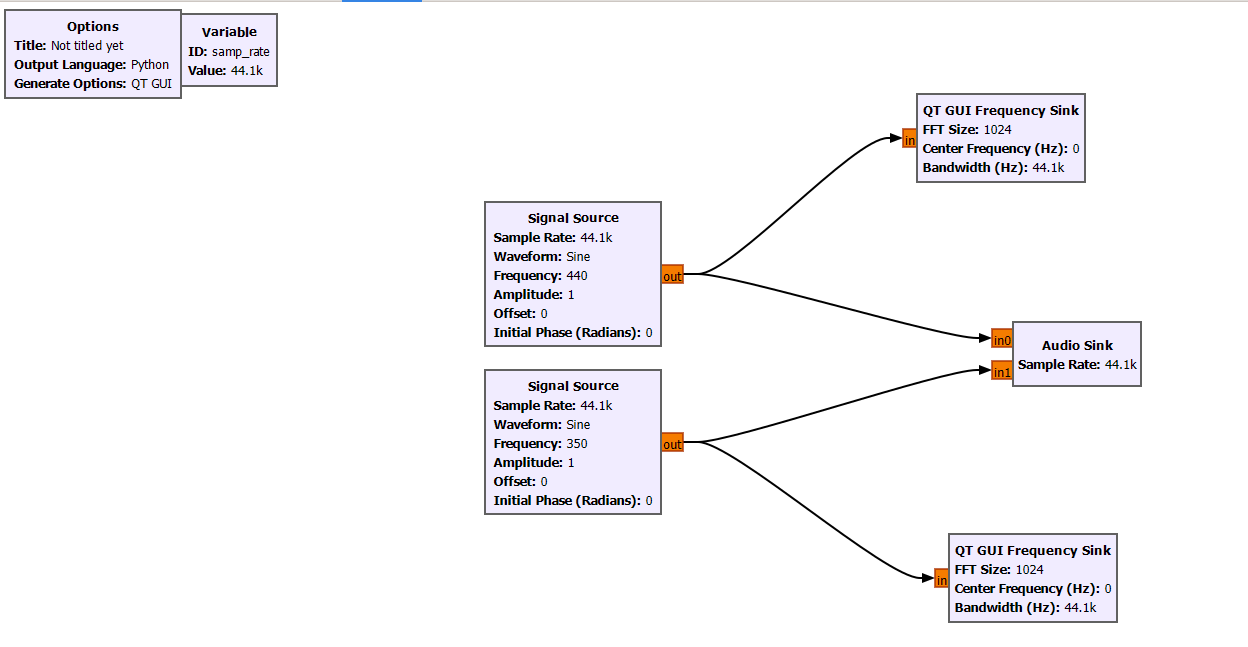